<a href="https://colab.research.google.com/github/yami-stack/machine_learning/blob/main/Experiments-ML/CSL701_CE48Machine_Learning_Lab_Exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Yash Manohar Tawate Roll No-CE48 Batch-CE03


Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load uploaded CSV file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Display first 5 rows
df.head()

Saving data.csv to data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [2]:
# Task 2: Explore the Dataset

# 1. Check missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 3. Check data types
print("\nColumn Data Types:")
print(df.dtypes)

# 4. Check target class distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# 5. Display class distribution as percentages
print("\nDiagnosis Distribution (%):")
print(df["diagnosis"].value_counts(normalize=True) * 100)

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Column Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis into numerical values
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Display shapes
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

# Display first 5 rows of X
print("\nFirst 5 rows of X:")
display(X.head())

# Display first 5 values of y
print("\nFirst 5 values of y:")
print(y.head())

# Check target values
print("\nTarget values:")
print(y.value_counts())

Feature matrix X shape: (569, 30)
Target vector y shape: (569,)

First 5 rows of X:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 values of y:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Target values:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

# Display the shape
print("Shape of standardized data:", X_scaled.shape)

# Check mean and standard deviation
print("\nMean of standardized features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation of standardized features:")
print(X_scaled.std(axis=0))

Shape of standardized data: (569, 30)

Mean of standardized features:
[-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16  1.87313551e-16  4.99502802e-17 -4.99502802e-17
  1.74825981e-16  4.74527662e-16  2.37263831e-16 -1.12388130e-16
 -1.12388130e-16 -1.31119486e-16 -1.52972733e-16  1.74825981e-16
  1.62338411e-16  0.00000000e+00  8.74129903e-17 -6.24378502e-18
 -8.24179623e-16  1.24875700e-17 -3.74627101e-16  0.00000000e+00
 -2.37263831e-16 -3.37164391e-16  7.49254203e-17  2.24776261e-16
  2.62238971e-16 -5.74428222e-16]

Standard deviation of standardized features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:

from sklearn.decomposition import PCA

# Create PCA with 2 principal components
pca = PCA(n_components=2)

# Transform the standardized data
X_pca = pca.fit_transform(X_scaled)

# Display shapes
print("Original data shape:", X_scaled.shape)
print("PCA transformed data shape:", X_pca.shape)

# Display first 5 rows
print("\nFirst 5 rows of PCA transformed data:")
print(X_pca[:5])

Original data shape: (569, 30)
PCA transformed data shape: (569, 2)

First 5 rows of PCA transformed data:
[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [6]:

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Print variance explained by each component
print("Variance explained by PC1:",
      explained_variance[0] * 100, "%")

print("Variance explained by PC2:",
      explained_variance[1] * 100, "%")

# Calculate cumulative explained variance
cumulative_variance = explained_variance.cumsum()

print("\nCumulative variance after PC1:",
      cumulative_variance[0] * 100, "%")

print("Cumulative variance after PC2:",
      cumulative_variance[1] * 100, "%")

Variance explained by PC1: 44.272025607526366 %
Variance explained by PC2: 18.97118204403308 %

Cumulative variance after PC1: 44.272025607526366 %
Cumulative variance after PC2: 63.243207651559445 %


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

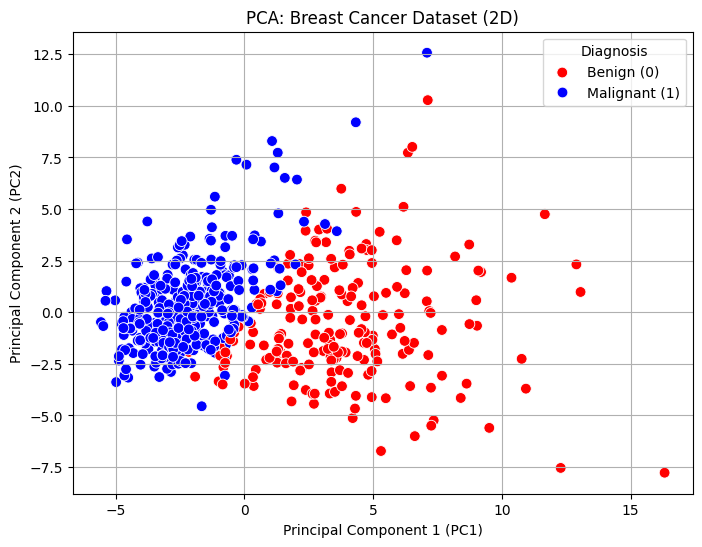

In [7]:

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette=["blue", "red"],
    s=60
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA: Breast Cancer Dataset (2D)")
plt.legend(title="Diagnosis", labels=["Benign (0)", "Malignant (1)"])
plt.grid(True)

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
logistic_model_raw = LogisticRegression(max_iter=1000)
logistic_model_raw.fit(X_train, y_train)

# Make predictions
y_pred_raw = logistic_model_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

# Confusion matrix
cm_raw = confusion_matrix(y_test, y_pred_raw)

# Classification report
report_raw = classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
)

print("Baseline Accuracy:", accuracy_raw)

print("\nConfusion Matrix:")
print(cm_raw)

print("\nClassification Report:")
print(report_raw)

Baseline Accuracy: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:

# Split the 2-component PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
logistic_model_pca = LogisticRegression(max_iter=1000)
logistic_model_pca.fit(X_train_pca, y_train_pca)

# Make predictions
y_pred_pca = logistic_model_pca.predict(X_test_pca)

# Calculate accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

# Confusion matrix
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

# Classification report
report_pca = classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
)

print("PCA Model Accuracy:", accuracy_pca)

print("\nConfusion Matrix:")
print(cm_pca)

print("\nClassification Report:")
print(report_pca)

PCA Model Accuracy: 0.9385964912280702

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [10]:

print("========== ACCURACY COMPARISON ==========")
print("Before PCA (30 Features):", accuracy_raw)
print("After PCA (2 Components):", accuracy_pca)

print("\n========== CONFUSION MATRIX: BEFORE PCA ==========")
print(cm_raw)

print("\n========== CONFUSION MATRIX: AFTER PCA ==========")
print(cm_pca)

print("\n========== CLASSIFICATION REPORT: BEFORE PCA ==========")
print(report_raw)

print("\n========== CLASSIFICATION REPORT: AFTER PCA ==========")
print(report_pca)

========== ACCURACY COMPARISON ==========
Before PCA (30 Features): 0.9649122807017544
After PCA (2 Components): 0.9385964912280702

========== CONFUSION MATRIX: BEFORE PCA ==========
[[71  1]
 [ 3 39]]

========== CONFUSION MATRIX: AFTER PCA ==========
[[71  1]
 [ 6 36]]

========== CLASSIFICATION REPORT: BEFORE PCA ==========
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


========== CLASSIFICATION REPORT: AFTER PCA ==========
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg   

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.